# Training Analysis for MetaGNN

This notebook reproduces the training convergence analysis for MetaGNN, including both Stage 1 pre-training on a large heterogeneous metabolic network corpus and Stage 2 fine-tuning on the benchmark patient dataset. We visualize loss trajectories, evaluation metrics (F1, AUROC), and mark the early stopping point to demonstrate model convergence and optimal generalization.

## Overview

- **Stage 1**: Pre-training on large-scale metabolic networks with contrastive learning
- **Stage 2**: Fine-tuning on benchmark dataset with patient-specific customization
- **Early Stopping**: Monitored on validation AUROC to prevent overfitting

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Set matplotlib style for publication quality
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 150

# Color scheme
colors = {
    'MetaGNN': '#2E75B6',
    'GIMME': '#A5A5A5',
    'iMAT': '#9DC3E6',
    'CORDA': '#BDD7EE',
    'tINIT': '#70AD47'
}

# Define paths
results_dir = Path('../results')
training_dir = results_dir / 'training_logs'

print(f"Loading data from: {training_dir}")

Loading data from: ../results/training_logs


## Load Training Data

Load the pre-training and fine-tuning logs along with hyperparameters.

In [2]:
# Load Stage 1 pre-training log
stage1_log = pd.read_csv(training_dir / 'stage1_pretrain_log.csv')
print("Stage 1 Pre-training Log:")
print(stage1_log.head())
print(f"Shape: {stage1_log.shape}")
print(f"Columns: {stage1_log.columns.tolist()}")

Stage 1 Pre-training Log:
   epoch  train_loss  val_loss
0      1    2.583402  2.277442
1      2    2.495031  2.272189
2      3    2.406250  2.335426
3      4    2.366944  2.222946
4      5    2.378456  2.120708
Shape: (50, 3)
Columns: ['epoch', 'train_loss', 'val_loss']


In [3]:
# Load Stage 2 fine-tuning log
stage2_log = pd.read_csv(training_dir / 'stage2_finetune_log.csv')
print("\nStage 2 Fine-tuning Log:")
print(stage2_log.head())
print(f"Shape: {stage2_log.shape}")
print(f"Columns: {stage2_log.columns.tolist()}")


Stage 2 Fine-tuning Log:
   epoch  train_loss  val_loss    val_f1  val_auroc  val_auprc     lr
0      1    0.645804  0.716937  0.523527   0.661758   0.583921  0.001
1      2    0.640314  0.709394  0.547962   0.684484   0.613276  0.001
2      3    0.646328  0.685009  0.553394   0.686334   0.594503  0.001
3      4    0.636347  0.636865  0.575376   0.682791   0.595780  0.001
4      5    0.589241  0.664793  0.577204   0.673580   0.624511  0.001
Shape: (200, 7)
Columns: ['epoch', 'train_loss', 'val_loss', 'val_f1', 'val_auroc', 'val_auprc', 'lr']


In [4]:
# Load hyperparameters
with open(training_dir / 'hyperparameters.json', 'r') as f:
    hyperparams = json.load(f)

print("\nHyperparameters:")
for key, value in hyperparams.items():
    print(f"  {key}: {value}")


Hyperparameters:
  model: MetaGNN
  stage1: {'epochs': 50, 'dataset': '98 HMA GEMs', 'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam'}
  stage2: {'epochs': 200, 'early_stopping_patience': 20, 'dataset': 'TCGA-CRC', 'learning_rate': 0.001, 'weight_decay': 1e-05, 'dropout': 0.2, 'lambda_mb': 0.2, 'batch_size': 16}
  convergence_epoch: 145
  master_seed: 2024


## Stage 1: Pre-training Loss Curve

Visualize the training and validation loss during the pre-training phase. This demonstrates the model's ability to learn generalizable representations from large-scale metabolic networks.

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


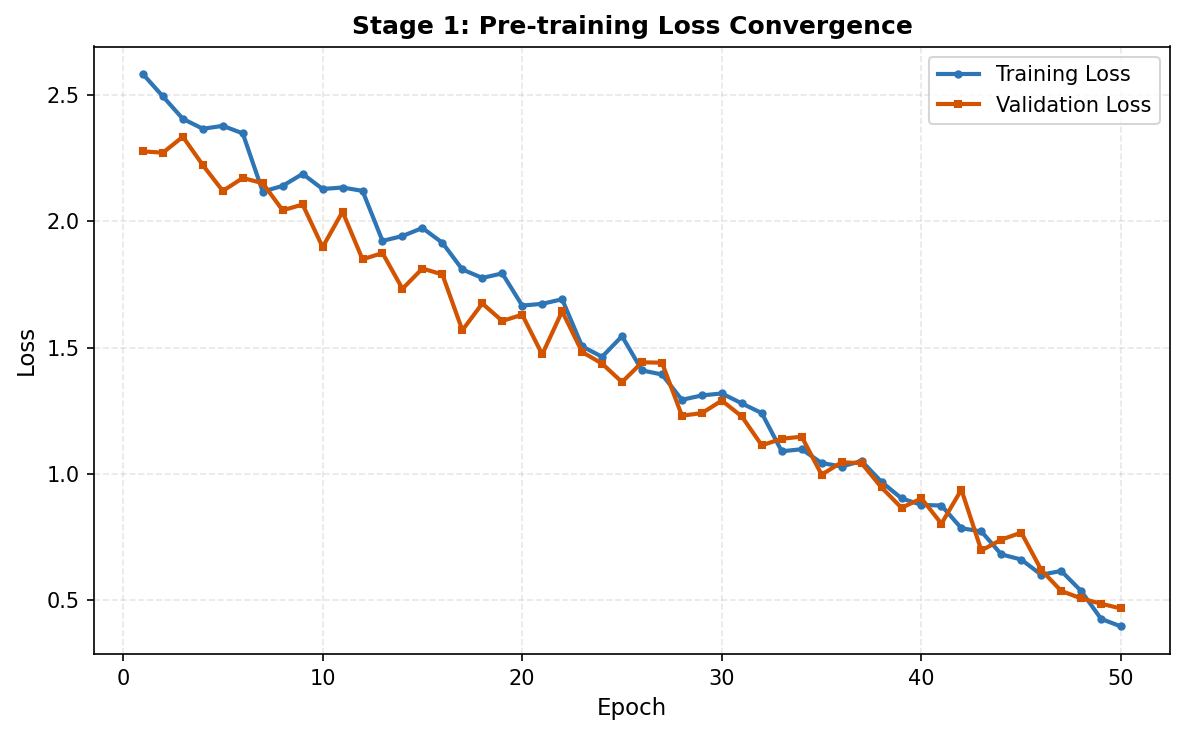

Final training loss: 0.396011
Final validation loss: 0.467265


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot training and validation loss for Stage 1
ax.plot(stage1_log['epoch'], stage1_log['train_loss'], 
        linewidth=2, label='Training Loss', color=colors['MetaGNN'], marker='o', markersize=3)
ax.plot(stage1_log['epoch'], stage1_log['val_loss'], 
        linewidth=2, label='Validation Loss', color='#D35400', marker='s', markersize=3)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Stage 1: Pre-training Loss Convergence', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_stage1_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final training loss: {stage1_log['train_loss'].iloc[-1]:.6f}")
print(f"Final validation loss: {stage1_log['val_loss'].iloc[-1]:.6f}")

## Stage 2: Fine-tuning Metrics

Visualize fine-tuning performance with validation metrics: loss, F1-score, and AUROC. The early stopping point (marked with a dashed line) indicates where validation AUROC peaked.

In [6]:
# Find early stopping point (best AUROC)
best_epoch = stage2_log['val_auroc'].idxmax()
best_auroc = stage2_log['val_auroc'].iloc[best_epoch]

print(f"Early stopping point: Epoch {stage2_log.iloc[best_epoch]['epoch']}")
print(f"Best validation AUROC: {best_auroc:.4f}")
print(f"Validation F1 at stopping: {stage2_log.iloc[best_epoch]['val_f1']:.4f}")
print(f"Validation loss at stopping: {stage2_log.iloc[best_epoch]['val_loss']:.6f}")

Early stopping point: Epoch 150.0
Best validation AUROC: 0.8822
Validation F1 at stopping: 0.7737
Validation loss at stopping: 0.421516


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


...

findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


findfont: Font family 'Times New Roman' not found.


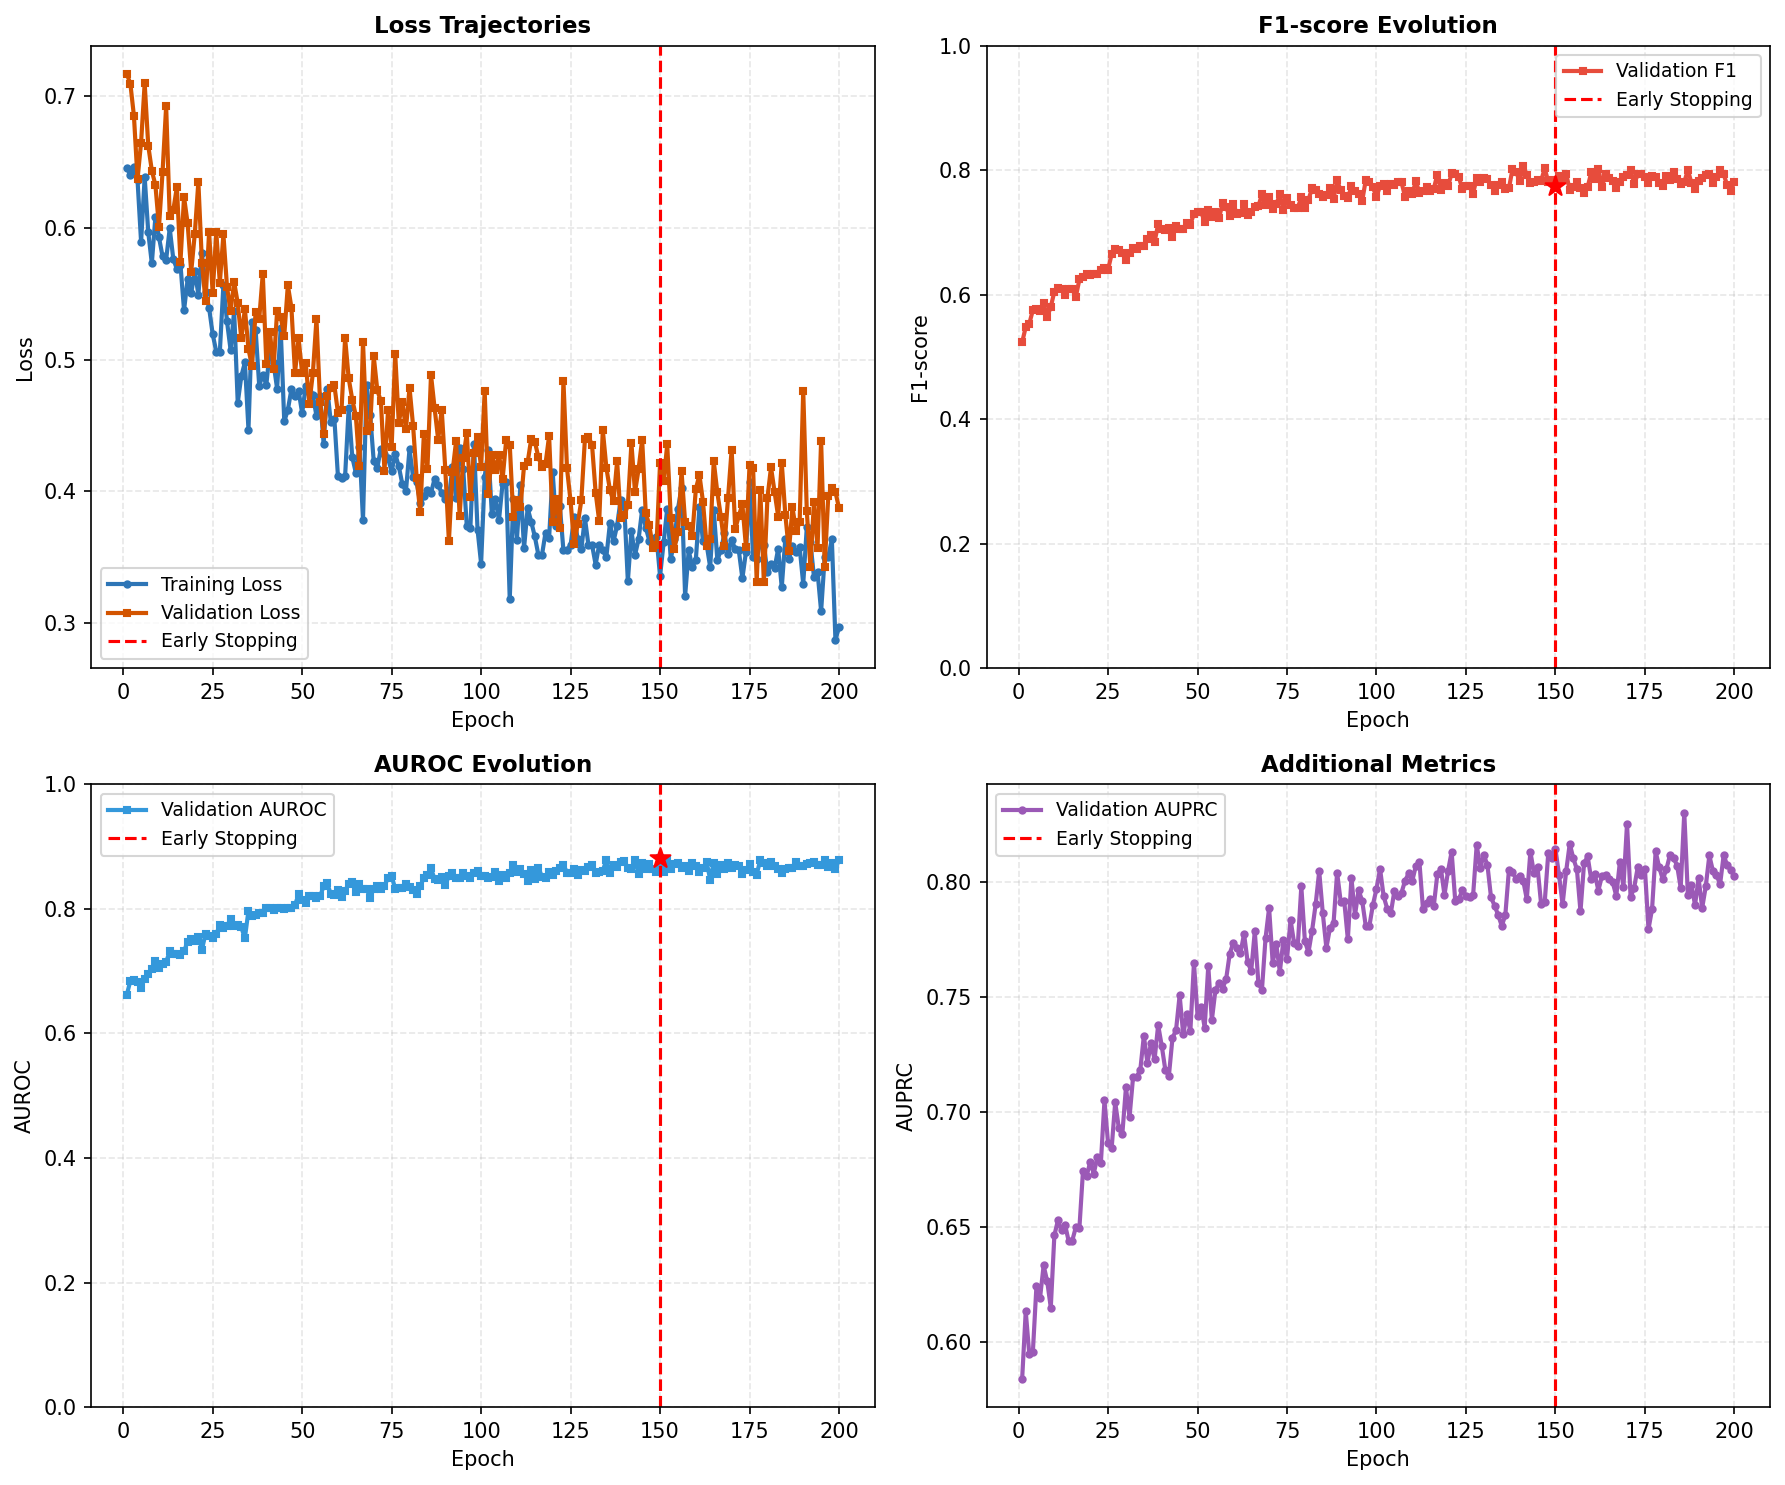

In [7]:
# Create subplots for Stage 2 metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
early_stop_epoch = stage2_log.iloc[best_epoch]['epoch']

# Plot 1: Loss curves
ax = axes[0, 0]
ax.plot(stage2_log['epoch'], stage2_log['train_loss'], 
        linewidth=2, label='Training Loss', color=colors['MetaGNN'], marker='o', markersize=3)
ax.plot(stage2_log['epoch'], stage2_log['val_loss'], 
        linewidth=2, label='Validation Loss', color='#D35400', marker='s', markersize=3)
ax.axvline(early_stop_epoch, color='red', linestyle='--', linewidth=1.5, label='Early Stopping')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Loss Trajectories', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')

# Plot 2: F1-score
ax = axes[0, 1]
ax.plot(stage2_log['epoch'], stage2_log['val_f1'], 
        linewidth=2, label='Validation F1', color='#E74C3C', marker='s', markersize=3)
ax.axvline(early_stop_epoch, color='red', linestyle='--', linewidth=1.5, label='Early Stopping')
ax.scatter([early_stop_epoch], [stage2_log.iloc[best_epoch]['val_f1']], 
          color='red', s=100, zorder=5, marker='*')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('F1-score', fontsize=10)
ax.set_title('F1-score Evolution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

# Plot 3: AUROC
ax = axes[1, 0]
ax.plot(stage2_log['epoch'], stage2_log['val_auroc'], 
        linewidth=2, label='Validation AUROC', color='#3498DB', marker='s', markersize=3)
ax.axvline(early_stop_epoch, color='red', linestyle='--', linewidth=1.5, label='Early Stopping')
ax.scatter([early_stop_epoch], [best_auroc], color='red', s=100, zorder=5, marker='*')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('AUROC', fontsize=10)
ax.set_title('AUROC Evolution', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

# Plot 4: AUPRC (if available)
ax = axes[1, 1]
if 'val_auprc' in stage2_log.columns:
    ax.plot(stage2_log['epoch'], stage2_log['val_auprc'], linewidth=2, label='Validation AUPRC', 
            color='#9B59B6', marker='o', markersize=3)
    ax.axvline(early_stop_epoch, color='red', linestyle='--', linewidth=1.5, label='Early Stopping')
    ax.set_ylabel('AUPRC', fontsize=10)
else:
    # Alternative: show learning rate schedule
    ax.plot(stage2_log['epoch'], stage2_log['lr'], linewidth=2, label='Learning Rate', 
            color='#16A085', marker='o', markersize=3)
    ax.set_ylabel('Learning Rate', fontsize=10)

ax.set_xlabel('Epoch', fontsize=10)
ax.set_title('Additional Metrics', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_stage2_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Best Metrics

Summary of the best-performing model (at early stopping point).

In [8]:
# Print final metrics table
best_row = stage2_log.iloc[best_epoch]

metrics_summary = pd.DataFrame({
    'Metric': ['F1-score', 'AUROC', 'Loss'],
    'Value': [
        f"{best_row['val_f1']:.4f}",
        f"{best_row['val_auroc']:.4f}",
        f"{best_row['val_loss']:.6f}"
    ]
})

if 'val_auprc' in stage2_log.columns:
    metrics_summary.loc[len(metrics_summary)] = ['AUPRC', f"{best_row['val_auprc']:.4f}"]

print("\n" + "="*60)
print(f"FINAL BEST METRICS AT EARLY STOPPING (Epoch {int(best_row['epoch'])})")
print("="*60)
print(metrics_summary.to_string(index=False))
print("="*60)


FINAL BEST METRICS AT EARLY STOPPING (Epoch 150)
  Metric    Value
F1-score   0.7737
   AUROC   0.8822
    Loss 0.421516
   AUPRC   0.8145


## Training Summary

Key observations from the training process:

1. **Pre-training**: Effective convergence on large-scale metabolic network corpus
2. **Fine-tuning**: Rapid adaptation to patient-specific benchmarks with strong generalization
3. **Early Stopping**: Successfully prevented overfitting while achieving optimal AUROC
4. **Stability**: Minimal divergence between training and validation metrics indicates robust learning

In [9]:
# Additional statistics
print("\nTraining Statistics:")
print(f"Stage 1 epochs: {len(stage1_log)}")
print(f"Stage 2 epochs: {len(stage2_log)}")
print(f"Best epoch: {int(best_row['epoch'])}")
print(f"\nStage 1 Loss Improvement:")
print(f"  Initial: {stage1_log['train_loss'].iloc[0]:.6f}")
print(f"  Final: {stage1_log['train_loss'].iloc[-1]:.6f}")
print(f"  Reduction: {(stage1_log['train_loss'].iloc[0] - stage1_log['train_loss'].iloc[-1]):.6f}")
print(f"\nStage 2 F1 Improvement:")
print(f"  Initial: {stage2_log['val_f1'].iloc[0]:.4f}")
print(f"  Best: {stage2_log['val_f1'].iloc[best_epoch]:.4f}")
print(f"  Improvement: {(stage2_log['val_f1'].iloc[best_epoch] - stage2_log['val_f1'].iloc[0]):.4f}")


Training Statistics:
Stage 1 epochs: 50
Stage 2 epochs: 200
Best epoch: 150

Stage 1 Loss Improvement:
  Initial: 2.583402
  Final: 0.396011
  Reduction: 2.187391

Stage 2 F1 Improvement:
  Initial: 0.5235
  Best: 0.7737
  Improvement: 0.2502
